In [1]:
import corner
import emcee
import matplotlib.pyplot as plt

In [2]:
import numpy as np
import scipy

Going to keep the seed of 6 - our group number (for debugging).

In [3]:
np.random.seed(seed=6)  # DEBUG

from polynomial_model import poly_generate_parmas, poly_model

Define variables and simulate the data:

In [6]:
sigma = 1  # the scale of Gaussian error
N_dim = 5
x = np.linspace(-2, 1, 100)
true_params = poly_generate_parmas(N_dim)
print("True parameters: ", true_params)
y_true = poly_model(true_params, x)
y_obs = y_true + scipy.stats.norm.rvs(0, sigma, len(x))


import polynomial_model
from polynomial_model import sample_mcmc

samples_mcmc = sample_mcmc(
true_params=true_params,
x=x,
y_obs=y_obs,
sigma=sigma,
nwalkers=50,
nsteps=8000,
burn_in=3000,
N_dim=N_dim,)

print(type(samples_mcmc))
print(samples_mcmc.shape)
print(samples_mcmc)

True parameters:  [ 2.20493167 -0.52253578  0.16566522  1.26805437  3.5959369 ]


100%|███████████████████████████████████████████████████████████| 8000/8000 [00:04<00:00, 1777.65it/s]

<class 'numpy.ndarray'>
(250000, 5)
[[ 2.01448165 -0.50273673 -0.18378222  1.15687873  3.65365789]
 [ 2.16155338 -0.7112002  -0.26062559  1.59372049  3.91286718]
 [ 2.13179329 -1.05035396  0.50636321  1.89131348  3.80301886]
 ...
 [ 2.06026317 -0.27851345 -0.08829386  0.83914273  3.50054651]
 [ 2.06445518 -0.39712602  0.32527785  1.58586998  3.77601241]
 [ 2.35488734  0.31896994 -0.05238479  0.58705546  3.47053465]]


In [7]:
import sbi
import torch
from sbi.analysis import pairplot
from sbi.inference import NPE
from sbi.utils import BoxUniform

print(sbi.__version__)

0.26.1


In [8]:
# Probably a good practice - redefine variables using torch objects
theta = torch.tensor(true_params)
x = torch.linspace(-2, 1, 100)
print(len(x))

100


In [15]:
def poly_model(theta, x):
    power = 0
    y = torch.zeros((len(x)))
    for t in theta:
        y += x**power * t
        power += 1
    return y


poly_model(theta, x)

_ = torch.manual_seed(6)


def simulator(theta):
    # Linear Gaussian.
    return poly_model(theta, x) + torch.randn_like(x)


prior = BoxUniform(
    low=-5.0 * torch.ones(N_dim),
    high=5.0 * torch.ones(N_dim),
)

num_simulations = 250000

theta_sim_list = []
x_sim_list = []

for _ in range(num_simulations):
    # sample one parameter vector from prior
    theta_i = prior.sample((1,))[0]  # (3,)
    x_i = simulator(theta_i)  # (N,)

    theta_sim_list.append(theta_i)
    x_sim_list.append(x_i)

theta_sim = torch.stack(theta_sim_list, dim=0)  # (num_simulations, 3)
x_sim = torch.stack(x_sim_list, dim=0)  # (num_simulations, N)

from functools import partial

import matplotlib.pyplot as plt
import torch
from sbi.analysis import pairplot
from sbi.inference import NPE
from sbi.neural_nets import posterior_nn

In [19]:
from realnvp import build_realnvp
print(x_sim.shape)
print(theta_sim.shape)

torch.Size([250000, 100])
torch.Size([250000, 5])


Now we define some different normalizing flows. RealNVP is implemented in 
realnvp.py, to save this file from cluttering.

In [20]:
models = {
    "RealNVP": partial(build_realnvp, hidden_features=128, num_transforms=10),
    "MAF": posterior_nn(
        model="maf",
        hidden_features=128,
        num_transforms=10,
        dropout_probability=0.0,
    ),
    "NSF": posterior_nn(
        model="nsf",
        hidden_features=128,
        num_transforms=10,
        num_bins=16,
        tail_bound=3.0,
    ),
}

In [21]:
samples_dict = {}
loss_dict = {}

for name, model in models.items():

    print(f"\nTraining {name}...\n")

    density_estimator_builder = model

    inference = NPE(
        prior=prior,
        density_estimator=density_estimator_builder,
    )

    density_estimator = inference.append_simulations(theta_sim, x_sim).train()

    posterior = inference.build_posterior(density_estimator)

    # posterior samples
    samples = posterior.sample(
        (250000,),
        x=y_obs,
    )

    samples_dict[name] = samples.detach()

    # training losses
    loss_dict[name] = inference


Training RealNVP...

 Neural network successfully converged after 62 epochs.

  0%|          | 0/250000 [00:00<?, ?it/s]


Training MAF...

 Neural network successfully converged after 71 epochs.

  0%|          | 0/250000 [00:00<?, ?it/s]


Training NSF...

 Neural network successfully converged after 39 epochs.

  0%|          | 0/250000 [00:00<?, ?it/s]

/Users/beermeester/.venvs/molten/lib/python3.12/site-packages/nflows/transforms/lu.py:80: UserWarning: torch.triangular_solve is deprecated in favor of torch.linalg.solve_triangularand will be removed in a future PyTorch release.
torch.linalg.solve_triangular has its arguments reversed and does not return a copy of one of the inputs.
X = torch.triangular_solve(B, A).solution
should be replaced with
X = torch.linalg.solve_triangular(A, B). (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/BatchLinearAlgebra.cpp:2265.)
  outputs, _ = torch.triangular_solve(


After training we can obtain the loss plot.

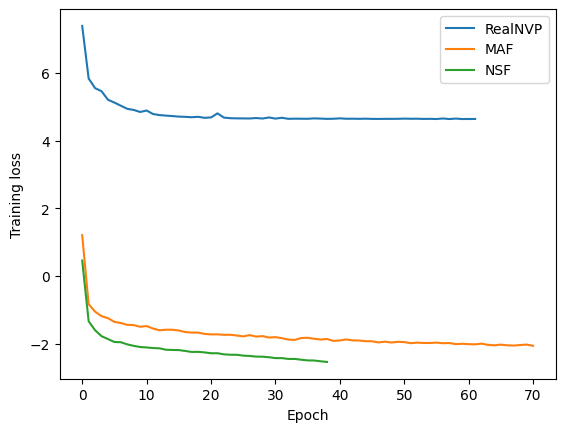

In [22]:
fig_loss, ax_loss = plt.subplots()
for key, val in loss_dict.items():
    ax_loss.plot(
        np.arange(len(val.summary["validation_loss"])),
        val.summary["training_loss"],
        label=key,
    )
ax_loss.set_xlabel("Epoch")
ax_loss.set_ylabel("Training loss")
ax_loss.legend()
plt.show()
plt.close(fig_loss)

We now generate a corner plot comparing MCMC with the different normalizing flows.

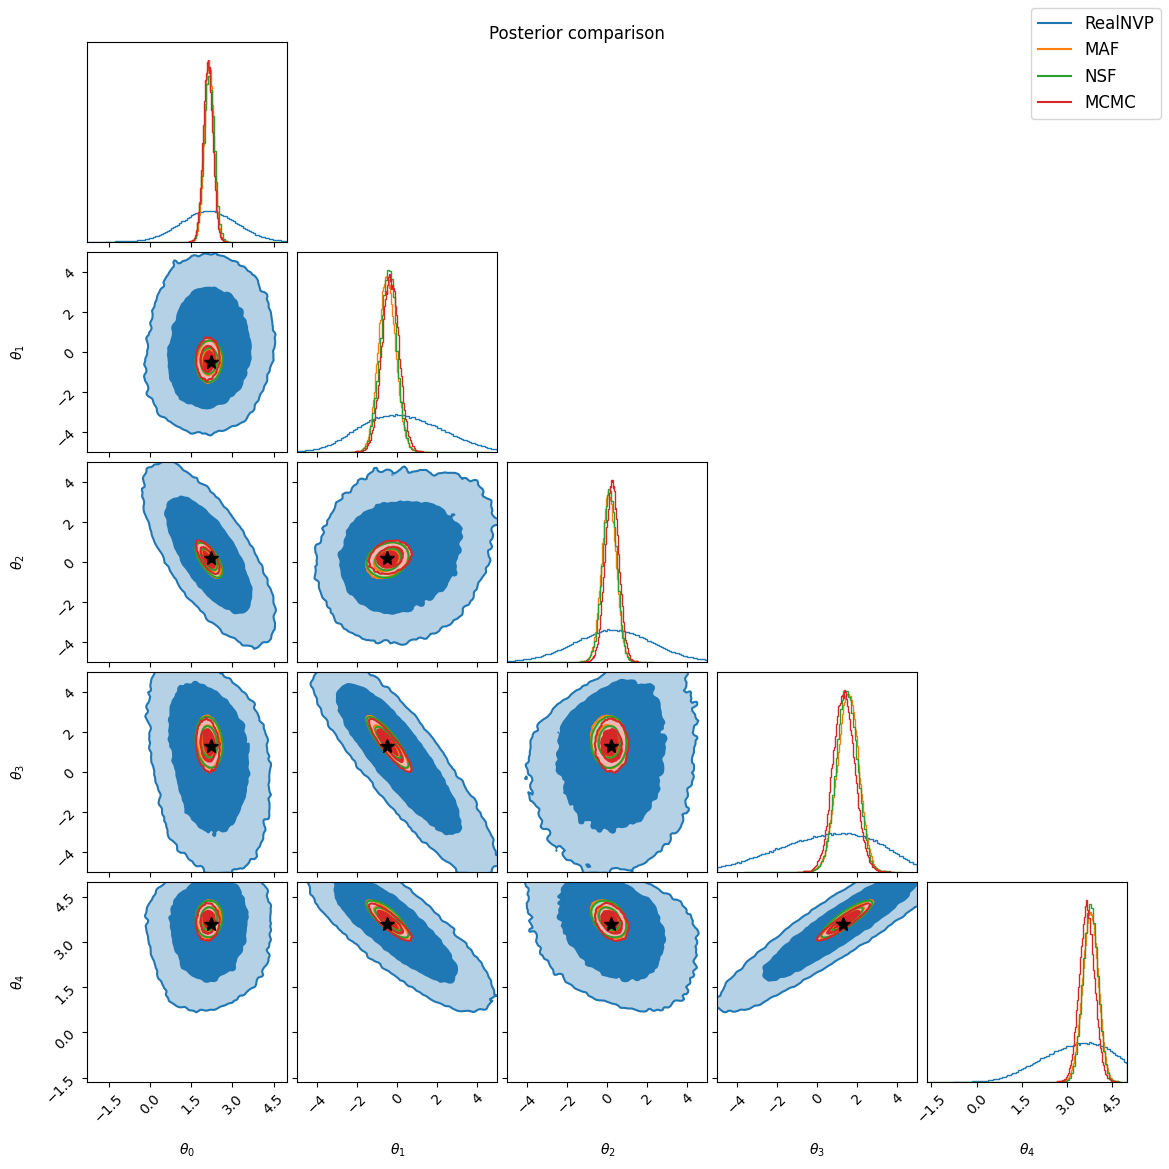

In [44]:
import corner

samples_dict["MCMC"] = torch.tensor(samples_mcmc)
colors = ["C0", "C1", "C2", "C3"]
labels = [rf"$\theta_{i}$" for i in range(theta_sim.shape[1])]

fig = None
for (name, samples), color in zip(samples_dict.items(), colors):
    fig = corner.corner(
        samples.numpy(),
        labels=labels,
        color=color,
        bins=100,
        smooth=1.0,
        fig=fig,
        plot_datapoints=False,
        plot_density=False,
        fill_contours=True,
        levels=(0.68, 0.95),
        hist_kwargs={"density":True}
    )

corner.overplot_points(
    fig,
    np.array(true_params).reshape(1, -1),
    marker="*",
    color="black",
    markersize=10,
)

handles = [
    plt.Line2D([0], [0], color=color, label=name)
    for color, name in zip(colors, samples_dict.keys())
]

fig.legend(handles=handles, loc="upper right", fontsize=12)
plt.suptitle("Posterior comparison")
plt.show()

In [45]:
import pandas as pd


In [46]:
table = pd.DataFrame({key: [val.summary['best_validation_loss'][0], val.summary['epochs_trained'][0], np.array(val.summary['validation_loss']).mean()]
                      for key, val in loss_dict.items() }, index = ['Best Validation Loss', 'Epochs Trained', 'Mean Validation Loss'])
table

,RealNVP,MAF,NSF
Best Validation Loss,4.637551,-2.140261,-2.306021
Epochs Trained,62.000000,71.000000,39.000000
Mean Validation Loss,4.755662,-1.725759,-2.077973
